# Network Optimisation

The baseline U-Net provides a first benchmark for the solar filament segmentation. On the local validation and test sets, the model achieved PQ scores of 0.327 and 0.292, respectively.

This notebook focuses on improving the segmentation pipeline by systematically evaluating different training configurations and network architectures.

The experiments will be performed incrementally, keeping the data split and evaluation protocol fixed to ensure a fair comparison between configurations.

The optimisation process will first focus on the existing U-Net architecture and training strategy. Once a strong U-Net baseline has been established, alternative architectures will be evaluated.

## Imports

In [11]:
from pathlib import Path
import sys
import random
from sklearn.model_selection import ParameterSampler
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_config, get_path
from src.utils.data import (
    get_train_images_dir,
    get_test_images_dir,
    get_annotations_path,
    load_annotations,
    remove_duplicate_annotations
)
from src.processing.masks import build_masks
from src.splitting.split import split_masks
from src.datasets.segmentation import SegmentationDataset, InferenceDataset
from src.training.dataloaders import create_dataloaders
from src.models.unet import UNet, ConfigurableUNet
from src.training.losses import BCEDiceLoss
from src.training.trainer import train_model
from src.processing.masks import get_connected_components, calculate_iou, filter_components_by_area
from src.utils.submission import (
    masks_to_submission,
    save_submission,
)
from src.models.utils import load_model
from src.inference.inference import predict_masks
from src.datasets.transforms import get_train_transforms
from src.processing.matching import (
    labeled_mask_to_instances,
    compare_instances,
)
from src.evalutation.evaluation import (
    evaluate_min_area,
    find_best_min_area,
)

PROJECT_ROOT = get_project_root()
CONFIG = load_config()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation


## Load data

In [2]:
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_data_dir"]

TRAIN_IMAGES_DIR = get_train_images_dir(RAW_DATA_DIR)
TEST_IMAGES_DIR = get_test_images_dir(RAW_DATA_DIR)
ANNOTATIONS_PATH = get_annotations_path(RAW_DATA_DIR)

annotations = load_annotations(ANNOTATIONS_PATH)

annotations_clean = remove_duplicate_annotations(annotations)

print(f"Images: {len(annotations_clean['images']):,}")
print(f"Annotations: {len(annotations_clean['annotations']):,}")

Images: 707
Annotations: 5,209


## Build masks

In [3]:
final_masks = build_masks(annotations_clean)

file_name = random.choice(list(final_masks.keys()))

mask = final_masks[file_name][0]

print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Splitting

### Data splitting strategy

Given the high computational cost of training segmentation models on **2048 × 2048 images**, performing cross-validation for every experiment would substantially increase the computational budget. Therefore, during the model optimization stage, we use a fixed **80/10/10 random split** consisting of 565 training, 71 validation, and 71 test images.

We also investigated the temporal distribution of the observations to assess whether a random split could introduce significant temporal leakage. After removing duplicated file names, most observations were temporally isolated, with **460 out of 571 temporal clusters containing a single image**. Therefore, no strong temporal grouping structure was identified that would justify a more restrictive temporal split.

The same fixed partitions will be used throughout the experiments to ensure a fair comparison between configurations. **Cross-validation may be applied afterwards to the final selected model** to obtain a more robust estimate of its performance.

In [4]:
train_masks, val_masks, test_masks = split_masks(
    final_masks,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    random_state=42,
)

train_dataset = SegmentationDataset(
    masks=train_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

val_dataset = SegmentationDataset(
    masks=val_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

test_dataset = SegmentationDataset(
    masks=test_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=1,
    num_workers=0,
    pin_memory=True,
)

print(f"Train:      {len(train_masks):,} images")
print(f"Validation: {len(val_masks):,} images")
print(f"Test:       {len(test_masks):,} images")
print(f"Total:      {len(final_masks):,} images")

Train:      565 images
Validation: 71 images
Test:       71 images
Total:      707 images


## Architecture hyperparameter optimization

The "ConfigurableUNet" allow us to investigate how the network architecture affects segmentation performance. Instead of exhaustively evaluating all possible combinations, we use a Random Search strategy to sample a limited number of configurations from the predefined parameter space.

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    
param_space = {
    "base_channels": [8, 16, 32],
    "depth": [3, 4, 5],
    "num_convs": [1, 2, 3],
    "kernel_size": [3, 5],
    "activation": [
        "relu",
        "leaky_relu",
        "gelu",
        "silu",
    ],
}

TRAINING_PARAMS = {
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "patience": 7,
    "scheduler_patience": 3,
    "scheduler_factor": 0.5,
    "threshold": 0.5,
    "device": device,
    "use_amp": True,
}

N_ITER = 15
RANDOM_STATE = 42

experiments = list(
    ParameterSampler(
        param_distributions=param_space,
        n_iter=N_ITER,
        random_state=RANDOM_STATE,
    )
)

print(f"Total possible configurations: 216")
print(f"Configurations sampled: {len(experiments)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070
Total possible configurations: 216
Configurations sampled: 15


In [11]:
loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

In [ ]:
results = []

for experiment_id, params in enumerate(
    experiments,
    start=1,
):

    print("\n" + "=" * 80)
    print(
        f"Experiment {experiment_id}/{N_ITER}"
    )
    print(params)
    print("=" * 80)

    model = ConfigurableUNet(
        **params,
    )
    

    checkpoint_path = (
        Path("artifacts/models")
        / f"architecture_search_{experiment_id:03d}.pth"
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        checkpoint_path=checkpoint_path,
        **TRAINING_PARAMS,
    )

    best_epoch = (
        history["val_dice"].index(
            max(history["val_dice"])
        )
        + 1
    )

    best_val_dice = max(
        history["val_dice"]
    )

    best_val_iou = max(
        history["val_iou"]
    )

    results.append(
        {
            "experiment": experiment_id,
            **params,
            "best_epoch": best_epoch,
            "best_val_dice": best_val_dice,
            "best_val_iou": best_val_iou,
            "checkpoint": str(
                checkpoint_path
            ),
        }
    )


Experiment 1/15
{'num_convs': 1, 'kernel_size': 5, 'depth': 3, 'base_channels': 32, 'activation': 'silu'}
Epoch 01/50 | Train Loss: 0.4023 | Train Dice: 0.3729 | Train IoU: 0.2514 | Val Loss: 0.2689 | Val Dice: 0.5004 | Val IoU: 0.3469 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5004)
Epoch 02/50 | Train Loss: 0.2530 | Train Dice: 0.5239 | Train IoU: 0.3677 | Val Loss: 0.3006 | Val Dice: 0.4281 | Val IoU: 0.2863 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 0.2367 | Train Dice: 0.5530 | Train IoU: 0.3942 | Val Loss: 0.3465 | Val Dice: 0.3617 | Val IoU: 0.2312 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 0.2349 | Train Dice: 0.5556 | Train IoU: 0.3966 | Val Loss: 0.2362 | Val Dice: 0.5487 | Val IoU: 0.3959 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5487)
Epoch 05/50 | Train Loss: 0.2180 | Train Dice: 0.5876 | Train IoU: 0.4269 | Val Loss: 0.2423 | Val Dice: 0.5383 | Val IoU: 0.3860 | LR: 1.00e-03
Epoch 06/50 | Train Loss: 0.2160 | Train Dice: 0.5914 | Train IoU: 0.4300 | Val Loss: 

## Conclusion of the architecture search

The architecture search shows that modifying the U-Net configuration provides only **minor improvements** over the baseline. Although some configurations achieve slightly better validation metrics, the gains are not substantial enough to justify continuing to explore increasingly fine-grained variations of the same architecture.

A consistent pattern can be observed across the experiments: **training metrics continue to improve with additional epochs, while validation metrics tend to plateau and fluctuate around a relatively stable level**. This suggests that the models continue to fit the training data without achieving a comparable improvement in generalization.

Therefore, we consider the current U-Net architecture to be **largely exhausted as a promising direction for further optimization**. Before moving to a fundamentally different approach, we will perform one final experiment by training the best configuration for a larger number of epochs **without early stopping**. This will allow us to determine whether the validation plateau is caused by stopping the training too early or represents a genuine limitation of the current approach.

If extended training does not produce a meaningful improvement, we will move towards a **different segmentation architecture or strategy**.

In [8]:
BEST_CONFIG = {
    "base_channels": 16,
    "depth": 5,
    "num_convs": 1,
    "kernel_size": 3,
    "activation": "gelu",
}

model = ConfigurableUNet(
    **BEST_CONFIG,
)

models_dir = get_path(CONFIG["paths"]["models_dir"])

loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    epochs=150,
    learning_rate=1e-3,
    weight_decay=0.0,
    patience=150,  # effectively disables early stopping
    scheduler_patience=15,
    scheduler_factor=0.5,
    threshold=0.5,
    device=device,
    use_amp=True,
    checkpoint_path=(
        models_dir
        / "best_unet_extended_training.pth"
    ),
)

Epoch 01/150 | Train Loss: 0.5267 | Train Dice: 0.2749 | Train IoU: 0.1829 | Val Loss: 0.3746 | Val Dice: 0.4172 | Val IoU: 0.2734 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.4172)
Epoch 02/150 | Train Loss: 0.2644 | Train Dice: 0.5248 | Train IoU: 0.3694 | Val Loss: 0.2461 | Val Dice: 0.5367 | Val IoU: 0.3836 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5367)
Epoch 03/150 | Train Loss: 0.2363 | Train Dice: 0.5548 | Train IoU: 0.3969 | Val Loss: 0.2776 | Val Dice: 0.4968 | Val IoU: 0.3438 | LR: 1.00e-03
Epoch 04/150 | Train Loss: 0.2288 | Train Dice: 0.5679 | Train IoU: 0.4080 | Val Loss: 0.2225 | Val Dice: 0.5776 | Val IoU: 0.4219 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5776)
Epoch 05/150 | Train Loss: 0.2126 | Train Dice: 0.5974 | Train IoU: 0.4370 | Val Loss: 0.2313 | Val Dice: 0.5614 | Val IoU: 0.4010 | LR: 1.00e-03
Epoch 06/150 | Train Loss: 0.2108 | Train Dice: 0.6006 | Train IoU: 0.4398 | Val Loss: 0.2258 | Val Dice: 0.5675 | Val IoU: 0.4131 | LR: 1.00e-03
E

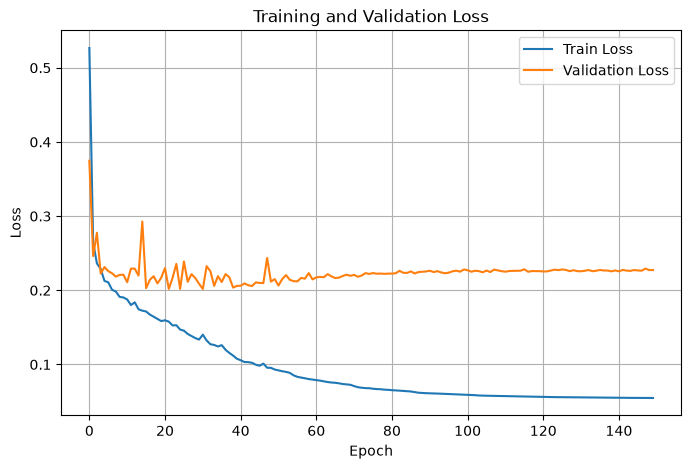

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

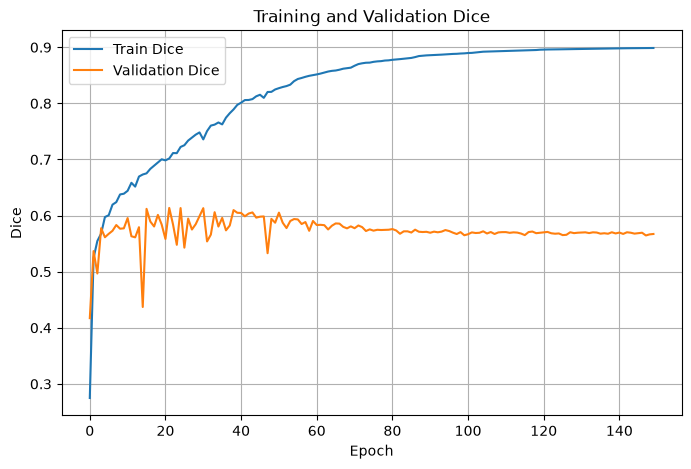

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Training and Validation Dice")
plt.legend()
plt.grid(True)
plt.show()

### Overfittin durgin exteded training

The extended training experiment revealed clear *overfitting*. Training metrics continued to improve with increasing epochs, while increasing epochs, while validation performance plateaued after a certain point and did not improve further.

## Data augmentation

In [5]:
train_transform = get_train_transforms(
    horizontal_flip_p=0.5,
    vertical_flip_p=0.5,
    rotation_p=1.0,
    rotation_degrees=(0, 360),
)

train_masks, val_masks, test_masks = split_masks(
    final_masks,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    random_state=42,
)

train_dataset = SegmentationDataset(
    masks=train_masks,
    images_dir=TRAIN_IMAGES_DIR,
    transform=train_transform,
)

val_dataset = SegmentationDataset(
    masks=val_masks,
    images_dir=TRAIN_IMAGES_DIR,
    transform=None,
)

test_dataset = SegmentationDataset(
    masks=test_masks,
    images_dir=TRAIN_IMAGES_DIR,
    transform=None,
)

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=1,
    num_workers=0,
    pin_memory=True,
)

images, masks_batch = next(iter(train_loader))

print(f"Train batches: {len(train_loader)}")
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape:  {masks_batch.shape}")

Train batches: 565
Image batch shape: torch.Size([1, 1, 2048, 2048])
Mask batch shape:  torch.Size([1, 1, 2048, 2048])


In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

Device: cuda


In [7]:
BEST_CONFIG = {
    "base_channels": 16,
    "depth": 5,
    "num_convs": 1,
    "kernel_size": 3,
    "activation": "gelu",
}

model = ConfigurableUNet(
    **BEST_CONFIG,
)

models_dir = get_path(CONFIG["paths"]["models_dir"])

loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    epochs=150,
    learning_rate=1e-3,
    weight_decay=0.0,
    patience=20,  
    scheduler_patience=10,
    scheduler_factor=0.5,
    threshold=0.5,
    device=device,
    use_amp=True,
    checkpoint_path=(
        models_dir
        / "best_unet_data_augmentation.pth"
    ),
)

Epoch 01/150 | Train Loss: 0.4913 | Train Dice: 0.3400 | Train IoU: 0.2306 | Val Loss: 0.3140 | Val Dice: 0.4868 | Val IoU: 0.3373 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.4868)
Epoch 02/150 | Train Loss: 0.2480 | Train Dice: 0.5507 | Train IoU: 0.3920 | Val Loss: 0.2356 | Val Dice: 0.5593 | Val IoU: 0.4042 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5593)
Epoch 03/150 | Train Loss: 0.2233 | Train Dice: 0.5802 | Train IoU: 0.4208 | Val Loss: 0.2261 | Val Dice: 0.5711 | Val IoU: 0.4189 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5711)
Epoch 04/150 | Train Loss: 0.2152 | Train Dice: 0.5935 | Train IoU: 0.4335 | Val Loss: 0.2622 | Val Dice: 0.4995 | Val IoU: 0.3560 | LR: 1.00e-03
Epoch 05/150 | Train Loss: 0.2109 | Train Dice: 0.6001 | Train IoU: 0.4406 | Val Loss: 0.2127 | Val Dice: 0.5938 | Val IoU: 0.4406 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5938)
Epoch 06/150 | Train Loss: 0.2076 | Train Dice: 0.6058 | Train IoU: 0.4474 | Val Loss: 0.2105 | Val Dice: 

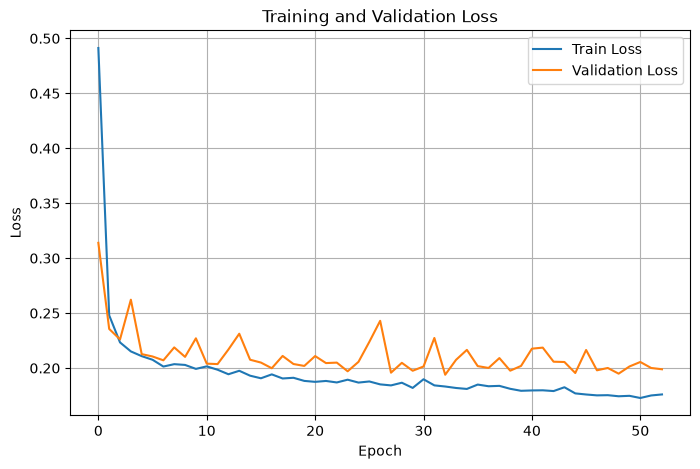

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

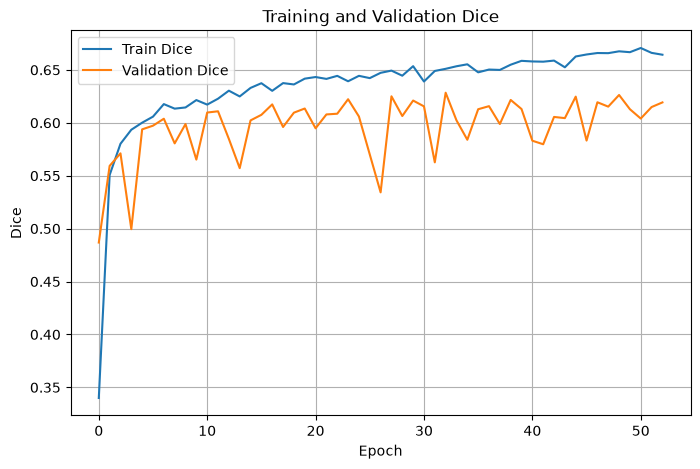

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Training and Validation Dice")
plt.legend()
plt.grid(True)
plt.show()

### Effect of data augmentation

The validation metrics obtained with data augmentation are **similar to those observed in previous experiments**, suggesting that the improvement in validation performance is relatively limited.

However, data augmentation has substantially reduced the gap between the training and validation metrics. The training Dice and IoU are now much closer to their validation counterparts, indicating that the model is **less prone to overfitting** and is generalizing more consistently to unseen data.

Therefore, although data augmentation has not yet produced a major improvement in validation performance, it has clearly improved the **training dynamics and generalization behavior** of the model.

## Submission

### Loading the pretrained model

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

BEST_CONFIG = {
    "base_channels": 16,
    "depth": 5,
    "num_convs": 1,
    "kernel_size": 3,
    "activation": "gelu",
}

models_dir = get_path(CONFIG["paths"]["models_dir"])
checkpoint_path=(
        models_dir
        / "best_unet_data_augmentation.pth"
    )

model = ConfigurableUNet(
    in_channels=1,
    out_channels=1,
    **BEST_CONFIG,
)

model = load_model(
    model=model,
    checkpoint_path=checkpoint_path,
    device=device,
)

print("Model loaded successfully.")

Device: cuda
GPU: NVIDIA GeForce RTX 4070
Model loaded successfully.


### Predictions over all validation set and comparison with ground-true filaments

In [7]:
all_comparisons = []

for index in range(len(val_dataset)):

    image, _ = val_dataset[index]
    filename = val_dataset.filenames[index]

    # ---------------------------------------------------------
    # Ground-truth instances
    # ---------------------------------------------------------
    gt_instances = val_masks[filename]

    # ---------------------------------------------------------
    # Model prediction
    # ---------------------------------------------------------
    predicted_mask = predict_masks(
        model=model,
        images=image.unsqueeze(0),
        device=device,
        threshold=0.5,
    )

    predicted_mask = (
        predicted_mask
        .squeeze()
        .cpu()
        .numpy()
    )

    # ---------------------------------------------------------
    # Connected components
    # ---------------------------------------------------------
    labeled_mask, num_components = get_connected_components(
        predicted_mask
    )

    predicted_instances = labeled_mask_to_instances(
        labeled_mask=labeled_mask,
        num_components=num_components,
    )

    # ---------------------------------------------------------
    # Compare prediction and ground truth
    # ---------------------------------------------------------
    comparison_df = compare_instances(
        predicted_instances=predicted_instances,
        gt_instances=gt_instances,
    )

    comparison_df["filename"] = filename

    all_comparisons.append(comparison_df)

validation_comparisons_df = pd.concat(
    all_comparisons,
    ignore_index=True,
)

validation_comparisons_df = validation_comparisons_df[
    [
        "filename",
        "pred_id",
        "gt_id",
        "iou",
        "area",
        "match_type",
    ]
].sort_values(
    ["filename", "pred_id", "gt_id"],
    na_position="last",
)

validation_comparisons_df

,filename,pred_id,gt_id,iou,area,match_type
1210,20110128174814Mh.jpeg,1.0,NaN,0.000000,43.0,FP
1211,20110128174814Mh.jpeg,2.0,1.0,0.155855,438.0,FP
1212,20110128174814Mh.jpeg,3.0,1.0,0.207388,496.0,FP
1213,20110128174814Mh.jpeg,4.0,1.0,0.018625,80.0,FP
1214,20110128174814Mh.jpeg,5.0,1.0,0.285966,706.0,FP
...,...,...,...,...,...,...
698,20220803074752Th.jpeg,9.0,NaN,0.000000,57.0,FP
699,20220803074752Th.jpeg,10.0,NaN,0.000000,422.0,FP
700,20220803074752Th.jpeg,11.0,2.0,0.623569,3429.0,TP
701,20220803074752Th.jpeg,NaN,5.0,0.000000,NaN,FN


In [8]:
min_area_values = range(0, 2001, 50)

area_results = find_best_min_area(
    predictions_df=validation_comparisons_df,
    min_area_values=min_area_values,
)

area_results.head(10)

,min_area,TP,FP,FN,SQ,RQ,PQ
0,600,287,175,259,0.671605,0.569444,0.382442
1,500,302,214,244,0.670261,0.568738,0.381203
2,650,279,164,267,0.672310,0.564206,0.379322
3,550,293,199,253,0.671058,0.564547,0.378844
4,450,305,234,241,0.669790,0.562212,0.376564
5,700,269,153,277,0.672496,0.555785,0.373763
6,400,310,256,236,0.668869,0.557554,0.372931
7,350,317,280,229,0.668504,0.554681,0.370806
8,750,260,144,286,0.673287,0.547368,0.368536
9,300,321,302,225,0.668622,0.549187,0.367199


In [9]:
best_min_area = int(
    area_results.iloc[0]["min_area"]
)

best_pq = area_results.iloc[0]["PQ"]

print(f"Best min_area: {best_min_area}")
print(f"Best validation PQ: {best_pq:.4f}")

Best min_area: 600
Best validation PQ: 0.3824


In [12]:
test_inference_dataset = InferenceDataset(
    images_dir=TEST_IMAGES_DIR,
)

test_inference_loader = DataLoader(
    test_inference_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [13]:
test_labeled_masks = {}

for images, filenames in test_inference_loader:

    predicted_masks = predict_masks(
        model=model,
        images=images,
        device=device,
        threshold=0.5,
    )

    for predicted_mask, filename in zip(
        predicted_masks,
        filenames,
    ):
        predicted_mask = (
            predicted_mask
            .squeeze()
            .cpu()
            .numpy()
        )

        labeled_mask, _ = get_connected_components(
            predicted_mask
        )

        filtered_labeled_mask = filter_components_by_area(
            labeled_mask=labeled_mask,
            min_area=best_min_area,
        )

        test_labeled_masks[filename] = filtered_labeled_mask

In [15]:
submission = masks_to_submission(
    labeled_masks=test_labeled_masks,
)

submissions_dir = get_path(
    CONFIG["paths"]["submissions_dir"]
)

submission_path = (
    submissions_dir
    / "second_submission.csv"
)

save_submission(
    submission=submission,
    output_path=submission_path,
)